# Phase 7 — Hero Figure

One PNG that summarizes the whole project. This is what goes at the top of the README
and what the PM sees first when opening the decision memo. It has to answer three
questions at a glance:

1. **What's the current state?** — blanket campaign losing money
2. **What are we recommending?** — targeted policy
3. **What's the payoff?** — net swing of ~$9.6k / month

## Design principles for a hero figure

- **Single takeaway** — don't try to show every metric
- **Clear before/after** — same units, same axes, side by side
- **Numbers on the bars** — readable without the legend
- **Muted colors for status quo, bright color for the recommendation**

Output: `reports/figures/07_hero_summary.png`.

In [1]:
import os
import sys
import pickle
from pathlib import Path

# Run from project root whether invoked as `python notebooks/07_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import load_production_churn_model
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER, PREMIUM_UPGRADE_CAP_PCT,
    pick_best_lever, apply_budget_cap, apply_premium_cap,
    summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Compute the two policies

Re-runs the Phase 6 policies (blanket baseline + $200k targeted) so the hero figure
always reflects the current model + assumptions.

In [2]:
raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Load via src/models/production.py -- same artifact as Streamlit + Phase 6.
model, artifact = load_production_churn_model()
X = X[artifact["feature_names"]]

p_churn = model.predict_proba(X)[:, 1]
ltv = df["plan_tier"].map(LTV_BY_TIER).values
tenure = df["tenure_months"].values

# Blanket m11 baseline
baseline = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=5.0, target_month=11, uplift=0.15,
)

# Targeted policy at $200k budget
policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
policy = apply_budget_cap(policy, budget=200_000)
policy = apply_premium_cap(policy, n_total=len(policy),
                           cap_pct=PREMIUM_UPGRADE_CAP_PCT)
targeted = summarize_policy(policy, targeted_only=True)

## Build the hero figure

Two panels: **left** = net EV comparison with the monthly swing annotated;
**right** = component breakdown (users contacted, cost, retained revenue, net EV).

Saved -> reports\figures\07_hero_summary.png

Hero figure summary:
  Blanket baseline net EV:  $    -4,798
  Targeted policy net EV:   $    19,087
  Monthly swing:            $    23,885


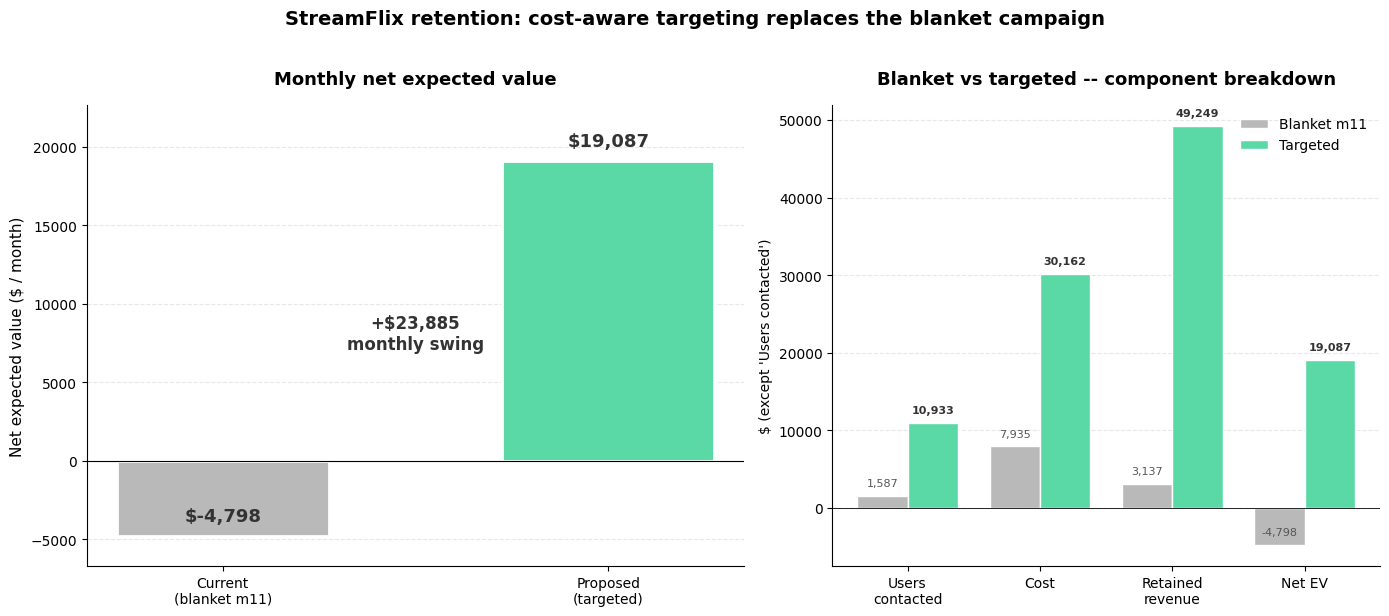

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={"width_ratios": [1.2, 1]})

# LEFT: net EV comparison (the money shot)
policies = ["Current\n(blanket m11)", "Proposed\n(targeted)"]
net_evs = [baseline["net_expected_value"], targeted["net_expected_value"]]
colors = ["#B9B9B9", "#5AD8A6"]

bars = ax1.bar(policies, net_evs, color=colors, edgecolor="white",
               width=0.55, linewidth=2)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Net expected value ($ / month)", fontsize=11)
ax1.set_title("Monthly net expected value",
              fontweight="bold", fontsize=13, pad=15)

# Pad the y-axis so labels for both positive and negative bars have room
# without colliding with the x-axis tick labels below the plot
axis_range = max(net_evs) - min(net_evs)
ax1.set_ylim(min(net_evs) - axis_range * 0.08,
             max(net_evs) + axis_range * 0.15)

for bar, val in zip(bars, net_evs):
    if val >= 0:
        # Positive bars: label above the top of the bar
        y_pos = val + axis_range * 0.03
        va = "bottom"
    else:
        # Negative bars: label INSIDE the bar (just above the base of the
        # bar, above the x-axis) so it doesn't collide with tick labels
        y_pos = val + axis_range * 0.03
        va = "bottom"
    ax1.text(bar.get_x() + bar.get_width() / 2, y_pos,
             f"${val:,.0f}", ha="center", va=va, fontsize=13,
             fontweight="bold",
             color="#333333")

# Annotate the swing
swing = targeted["net_expected_value"] - baseline["net_expected_value"]
ax1.annotate(
    f"+${swing:,.0f}\nmonthly swing",
    xy=(1, targeted["net_expected_value"]),
    xytext=(0.5, (baseline["net_expected_value"] + targeted["net_expected_value"]) / 2),
    ha="center", fontsize=12, fontweight="bold", color="#333333",
)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# RIGHT: breakdown of the four metrics side by side
metrics = ["Users\ncontacted", "Cost", "Retained\nrevenue", "Net EV"]
blanket_vals = [
    baseline["n_targeted"],
    baseline["total_cost"],
    baseline["expected_retained_revenue"],
    baseline["net_expected_value"],
]
targeted_vals = [
    targeted["n_targeted"],
    targeted["total_cost"],
    targeted["expected_retained_revenue"],
    targeted["net_expected_value"],
]

x_pos = np.arange(len(metrics))
width = 0.38

bars1 = ax2.bar(x_pos - width / 2, blanket_vals, width,
                label="Blanket m11", color="#B9B9B9", edgecolor="white")
bars2 = ax2.bar(x_pos + width / 2, targeted_vals, width,
                label="Targeted", color="#5AD8A6", edgecolor="white")

ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylabel("$ (except 'Users contacted')", fontsize=10)
ax2.set_title("Blanket vs targeted -- component breakdown",
              fontweight="bold", fontsize=13, pad=15)
ax2.legend(fontsize=10, loc="upper right", frameon=False)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Value labels on the bars -- for negative bars, put the label INSIDE
# the bar (above the base) so it doesn't collide with the x-axis labels
max_val = max(blanket_vals + targeted_vals)
label_offset = max_val * 0.02

for b, v in zip(bars1, blanket_vals):
    y_pos = v + label_offset if v >= 0 else v + label_offset
    ax2.text(b.get_x() + b.get_width() / 2, y_pos,
             f"{v:,.0f}", ha="center", va="bottom",
             fontsize=8, color="#555555")
for b, v in zip(bars2, targeted_vals):
    y_pos = v + label_offset if v >= 0 else v + label_offset
    ax2.text(b.get_x() + b.get_width() / 2, y_pos,
             f"{v:,.0f}", ha="center", va="bottom",
             fontsize=8, color="#333333",
             fontweight="bold")

plt.suptitle(
    "StreamFlix retention: cost-aware targeting replaces the blanket campaign",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
out_path = FIG_DIR / "07_hero_summary.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
print(f"Saved -> {out_path}")

print("\nHero figure summary:")
print(f"  Blanket baseline net EV:  ${baseline['net_expected_value']:>10,.0f}")
print(f"  Targeted policy net EV:   ${targeted['net_expected_value']:>10,.0f}")
print(f"  Monthly swing:            ${swing:>10,.0f}")